# CAN FD带练：从12字节到多节点反馈

配套正文：[CAN FD连续带练](../engineering/04_canfd.md#worked-lessons)。本实验的ID与数据格式是教学自定的，不是电机指令；所有数据只在内存中处理。完成后应能手算字段、解释重复/回绕、检查接收年龄，并发现错误输入不会更新状态。

每节按“先预测→运行→改一个输入→解释”完成。代码不会打开适配器，也不提供真实硬件发送功能。


In [1]:
from pathlib import Path
import sys, math, csv, json

# Locate the course even when the kernel starts in notebooks/.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "labs" / "course_lab.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the complete trainning_materials folder.")
sys.path.insert(0, str(ROOT / "labs"))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, HTML
import ipywidgets as widgets
from course_lab import fk, ik, encode_frame, decode_frame, feedback_fresh, sphere_gap, fit_line, mse
from algorithm_lab import jacobian, numerical_ik, astar, trapezoid, kalman_step, pid_demo
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})
print("Python:", sys.executable)
print("Course:", ROOT.name)


Python: D:\code_agent\trainning_materials\.venv\Scripts\python.exe
Course: trainning_materials


In [2]:
from workshop_lab import Frame, FeedbackRouter, pack_feedback, unpack_feedback
from engineering_lab import fd_layout


## 1. 先手算负数，再核对黄金字节
节点2、序号65535、位置−250mrad、速度100mrad/s、电流−500mA。先写出−250的32位补码以及−500的16位补码，再看结果。为什么4字节位置比2字节速度有更大范围？


In [3]:
raw = pack_feedback(2, 65535, -250, 100, -500)
golden = bytes.fromhex("D1 02 FF FF 06 FF FF FF 64 00 0C FE")
print("bytes:", raw.hex(" "), "length:", len(raw))
print("decoded:", unpack_feedback(raw))
assert raw == golden
assert unpack_feedback(golden)["position_rad"] == -.25


bytes: d1 02 ff ff 06 ff ff ff 64 00 0c fe length: 12
decoded: {'node': 2, 'sequence': 65535, 'position_rad': -0.25, 'velocity_rad_s': 0.1, 'current_a': -0.5}


## 2. 长度错误不能靠补零掩盖
预测删一字节、改标记、超出int16范围的行为。每个错误都在进入运动或发布状态前发现。正常解码不等于实际电流和轴侧已验证，真机还要对照对应协议。


In [4]:
for label, value in [("truncated", raw[:-1]), ("bad opcode", b"\xa1" + raw[1:])]:
    try:
        unpack_feedback(value)
    except ValueError as error:
        print(label, "rejected:", error)
    else:
        raise AssertionError("Invalid payload was accepted")
try:
    pack_feedback(2, 0, 0, 0, 40000)
except ValueError as error:
    print("current range rejected:", error)


truncated rejected: Teaching feedback requires exactly 12 bytes
bad opcode rejected: Wrong teaching opcode or node
current range rejected: current must be an integer in [-32768, 32767]


## 3. DLC与字节数不是同一列
先预测9、25、33字节应用载荷需要多少承载空间，再打印。填充的值和接收方如何识别有效字段需要应用协议约定。


In [5]:
for length in (8, 9, 12, 25, 33, 64):
    print(fd_layout(length))


{'application_bytes': 8, 'dlc': 8, 'wire_bytes': 8, 'padding_bytes': 0}
{'application_bytes': 9, 'dlc': 9, 'wire_bytes': 12, 'padding_bytes': 3}
{'application_bytes': 12, 'dlc': 9, 'wire_bytes': 12, 'padding_bytes': 0}
{'application_bytes': 25, 'dlc': 13, 'wire_bytes': 32, 'padding_bytes': 7}
{'application_bytes': 33, 'dlc': 14, 'wire_bytes': 48, 'padding_bytes': 15}
{'application_bytes': 64, 'dlc': 15, 'wire_bytes': 64, 'padding_bytes': 0}


## 4. 重放重复、回绕、旧序号和错误设备
用一条通道统一接收，路由到节点2与3。节点3没有有效反馈，不能被节点2的数据“带着变新”。先在纸上预测八个事件的accept结果。


In [6]:
router = FeedbackRouter({(0, 0x282): 2, (0, 0x283): 3})
frames = [
    Frame(0, 0x282, 1.000, pack_feedback(2, 65535, -250, 100, -500)),
    Frame(0, 0x282, 1.010, pack_feedback(2, 0, -250, 100, -500)),
    Frame(0, 0x282, 1.020, pack_feedback(2, 0, 999, 100, -500)),
    Frame(0, 0x282, 1.030, pack_feedback(2, 65535, 999, 100, -500)),
    Frame(0, 0x999, 1.040, raw),
    Frame(0, 0x282, 1.050, pack_feedback(3, 1, 999, 0, 0)),
    Frame(0, 0x282, 1.060, pack_feedback(2, 1, 999, 0, 0), is_fd=False),
    Frame(0, 0x282, 1.070, raw[:-1]),
]
trace = []
for frame in frames:
    result = router.accept(frame)
    trace.append({"time_s": frame.received_s, "result": result})
    print(trace[-1])
assert [r["result"] for r in trace[:4]] == ["accepted", "accepted", "duplicate", "old_or_ambiguous_sequence"]


{'time_s': 1.0, 'result': 'accepted'}
{'time_s': 1.01, 'result': 'accepted'}
{'time_s': 1.02, 'result': 'duplicate'}
{'time_s': 1.03, 'result': 'old_or_ambiguous_sequence'}
{'time_s': 1.04, 'result': 'unmapped_id'}
{'time_s': 1.05, 'result': 'node_mismatch'}
{'time_s': 1.06, 'result': 'wrong_frame_type'}
{'time_s': 1.07, 'result': 'invalid_payload'}


## 5. 最后收到字节与最后有效反馈相差多少
1.080s检查时，节点2最后接受的是1.010s，接收年龄70ms。重复帧中的999不能覆盖−250。节点3是从未收到，不是位置为0。


{'channel': 0, 'can_id': 642, 'node': 2, 'receive_age_s': 0.07000000000000006, 'fresh': False, 'value': {'node': 2, 'sequence': 0, 'position_rad': -0.25, 'velocity_rad_s': 0.1, 'current_a': -0.5, 'received_s': 1.01}}
{'channel': 0, 'can_id': 643, 'node': 3, 'receive_age_s': None, 'fresh': False, 'value': None}


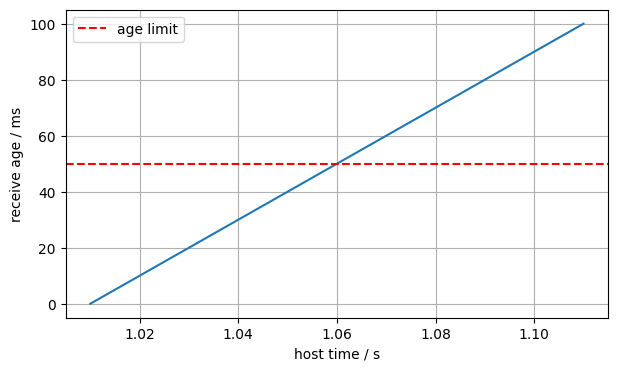

In [7]:
snapshot = router.snapshot(1.080, .050)
for row in snapshot:
    print(row)
assert abs(snapshot[0]["receive_age_s"] - .07) < 1e-12
assert not snapshot[0]["fresh"]
assert snapshot[0]["value"]["position_rad"] == -.25
assert snapshot[1]["value"] is None
times = [1.01 + .001*i for i in range(101)]
ages = [router.snapshot(t, .05)[0]["receive_age_s"]*1000 for t in times]
plt.plot(times, ages)
plt.axhline(50, linestyle="--", color="red", label="age limit")
plt.xlabel("host time / s"); plt.ylabel("receive age / ms"); plt.legend(); plt.show()


## 6. 改节点数，看仅载荷预算怎样增长
下图只算双向载荷，不包含仲裁、CRC、填充、帧间隔与主机调度。因此100%以下并不代表可部署，100%以上则已连乐观下界都装不下。


interactive(children=(IntSlider(value=6, description='nodes', max=12, min=1), IntSlider(value=1000, descriptio…

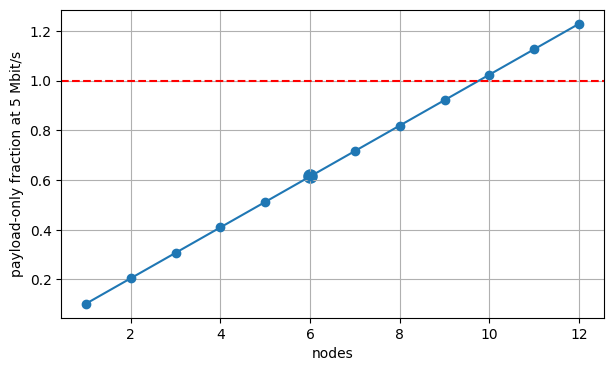

selected payload fraction: 0.6144


In [8]:
def payload_budget(nodes=6, frequency=1000):
    fractions = [n*frequency*2*32*8/5_000_000 for n in range(1, 13)]
    plt.plot(range(1, 13), fractions, "o-")
    plt.axhline(1, color="red", ls="--")
    plt.scatter([nodes], [fractions[nodes-1]], s=90)
    plt.xlabel("nodes"); plt.ylabel("payload-only fraction at 5 Mbit/s"); plt.show()
    print("selected payload fraction:", fractions[nodes-1])
display(widgets.interactive(payload_budget, nodes=widgets.IntSlider(value=6, min=1, max=12),
                            frequency=widgets.IntSlider(value=1000, min=100, max=2000, step=100)))
payload_budget()


## 7. 提交自己的故障回放
增加一条合法节点3帧、一个错误通道、一次时间倒退；逐条解释结果。设备重启时为什么应新建会话而不是继续旧序号？半序号空间比较有何前提？

解析：合法节点3只更新它自己的状态；错误通道不应自动路由；主机记录时间倒退应拒绝。序号回绕规则依赖连续会话和有限间隔，设备重启需要重新建立身份/状态。


In [9]:
out = ROOT / "outputs" / "workshop_canfd_trace.json"
out.parent.mkdir(exist_ok=True)
out.write_text(json.dumps({"scope": "invented offline packet", "events": trace, "snapshot": snapshot},
                          indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print("Saved:", out)


Saved: D:\code_agent\trainning_materials\outputs\workshop_canfd_trace.json
